# HCD-302 Creating Explainable AI — Lab 2
## Imbalance, Thresholds and Bias on a Loan Dataset

*ตรวจหาความไม่สมดุลของคลาส เลือกเมทริกและ threshold ให้ตรงกับต้นทุน แล้วตรวจสอบอคติของโมเดลเป็นราย slice*

| | |
|---|---|
| **รายวิชา** | HCD-302 Creating Explainable AI |
| **สัปดาห์** | 3 · Class Imbalance and Bias Detection in Data |
| **ผู้สอน** | ผศ.ดร.ฐิตินันท์ เกลี้ยงสุวรรณ |
| **เวลาทำแลป** | ในคาบประมาณ 30 นาที หลัง Quiz 1 และเลกเชอร์ (พฤหัสบดี 15.30–17.20 น. ห้อง COC-404) |
| **กำหนดส่ง** | วันพฤหัสบดีที่ทำแลป ก่อนเวลา 18.00 น. ผ่าน LMS (lms.psu.ac.th) |
| **สิ่งที่ส่ง** | ไฟล์ `HCD302_Lab2_<รหัสนักศึกษา>.ipynb` ที่ **รันผลลัพธ์ไว้แล้ว** — ไฟล์ที่ไม่มีผลลัพธ์จะไม่ได้รับการตรวจ |
| **คะแนน** | 100 คะแนน คิดเป็นส่วนหนึ่งของคะแนน Lab (15% ของรายวิชา) · ทำเป็นรายบุคคล |

### 1. วัตถุประสงค์
เมื่อทำแลปนี้เสร็จ นักศึกษาจะสามารถ
1. วัดสัดส่วนคลาส และแสดงให้เห็นว่า accuracy ของ `DummyClassifier` สูงเพียงใดโดยไม่เรียนรู้อะไรเลย
2. เลือกและอ่านเมทริกที่ทนต่อความไม่สมดุล (precision, recall, PR-AUC, balanced accuracy, MCC)
3. เลือก decision threshold จากข้อจำกัดเชิงปฏิบัติการบน validation set แทนการใช้ค่า 0.5 โดยปริยาย
4. ใช้ `class_weight` และ `SMOTE` ให้ถูกวิธี โดยวาง sampler ไว้ใน `imblearn.pipeline.Pipeline` และเห็นด้วยตัวเลขว่าการทำผิดลำดับให้ผลหลอกตาแค่ไหน
5. ตรวจสอบโมเดลเป็นราย slice ระบุกลุ่มที่แย่ที่สุด และบอกได้ว่าอคตินั้นมาจากแหล่งใดใน 5 แหล่ง

### 2. สถานการณ์
ธนาคารแห่งหนึ่งขอให้เราสร้างแบบจำลองทำนายการ**ผิดนัดชำระ** (`default`) ของใบสมัครสินเชื่อ
ทีมตรวจสอบมีกำลังคนจำกัด: **ตรวจได้ไม่เกินวันละประมาณ 8% ของใบสมัครที่เข้ามา** และหัวหน้าทีมบอกว่า
"ถ้าเราต้องเปิดดู 10 เคส แล้วเจอของจริงไม่ถึง 1 เคส ทีมจะเลิกใช้ระบบภายในสองสัปดาห์"

ประโยคสองประโยคนี้คือ **ข้อจำกัดเชิงปฏิบัติการ** ที่เราจะแปลงเป็น threshold ในงานที่ 3

### 3. ข้อกำหนด
- ห้ามแก้ไขฟังก์ชัน `generate_loan_data` และห้ามเปลี่ยนค่า seed
- ห้ามใช้ `applicant_id` และ `default` เป็น feature
- ทุกการ resample ต้องเกิดขึ้น**ภายใน pipeline** และกับ**ข้อมูลฝึกเท่านั้น**
- ทุกเมทริกที่รายงาน ต้องมีค่าของ `DummyClassifier` และสัดส่วนคลาสอยู่ข้าง ๆ เสมอ

### 4. การกระจายคะแนน (รวม 100)
| งาน | หัวข้อ | คะแนน |
|---|---|---|
| 1 | Diagnose — วัดความไม่สมดุลและ baseline | 15 |
| 2 | Metrics — เลือกและอ่านเมทริกให้ถูก | 20 |
| 3 | Threshold — แปลงข้อจำกัดเป็นตัวเลข | 20 |
| 4 | Resample — ทำให้ถูกลำดับและอธิบายกลไกได้ | 30 |
| 5 | Audit — หา slice ที่แย่ที่สุดและระบุแหล่งของอคติ | 15 |

---

## 0. Setup
รันเซลล์นี้ก่อน — ต้องการ `scikit-learn ≥ 1.2` และ `imbalanced-learn ≥ 0.11`
ถ้ายังไม่มี `imbalanced-learn` ให้รัน `pip install imbalanced-learn` หนึ่งครั้ง (บน Colab ใช้ `!pip install -q imbalanced-learn`)

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, matthews_corrcoef,
                             precision_score, recall_score, f1_score, fbeta_score,
                             average_precision_score, roc_auc_score,
                             precision_recall_curve, confusion_matrix, classification_report)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN = True
except ImportError:            # ถ้ายังไม่ได้ติดตั้ง ให้รัน pip install imbalanced-learn แล้วรันเซลล์นี้ใหม่
    IMBLEARN = False
    print("!! ยังไม่มี imbalanced-learn — งานที่ 4 จะทำไม่ได้ ให้รัน: pip install imbalanced-learn")

RANDOM_STATE = 42
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
print("scikit-learn", sklearn.__version__, "| imbalanced-learn พร้อมใช้งาน:", IMBLEARN)

scikit-learn 1.6.1 | imbalanced-learn พร้อมใช้งาน: True


### 0.1 ชุดข้อมูล
ชุดข้อมูลสร้างขึ้นในเซลล์ถัดไปแบบ deterministic (seed 303) ทุกเครื่องจะได้ข้อมูลชุดเดียวกัน **ไม่ต้องดาวน์โหลดไฟล์ใด ๆ**

| คอลัมน์ | ความหมาย |
|---|---|
| `age` | อายุผู้สมัคร (ปี) |
| `monthly_income` | รายได้ต่อเดือนที่บันทึกไว้ (บาท) — **มีค่าว่าง และค่าที่คลาดเคลื่อนไม่เท่ากันในแต่ละกลุ่ม** |
| `debt_to_income` | อัตราส่วนหนี้ต่อรายได้ |
| `credit_history_months` | ความยาวประวัติเครดิต (เดือน) — ต่ำกว่า 12 เดือนถือว่า *thin file* |
| `n_late_12m` | จำนวนครั้งที่ชำระล่าช้าใน 12 เดือนที่ผ่านมา |
| `loan_amount` | วงเงินที่ขอ (บาท) |
| `employment_type` | ประเภทการจ้างงาน |
| `region` | ภูมิภาค |
| `default` | **target** 1 = ผิดนัดชำระ |

In [2]:
# 0.1 — สร้างชุดข้อมูล loan_applications (deterministic: seed 303 → ทุกเครื่องได้ข้อมูลชุดเดียวกัน)
# ห้ามแก้ไขฟังก์ชันนี้และห้ามเปลี่ยน seed
def generate_loan_data(n=30000, seed=303):
    """ชุดข้อมูลใบสมัครสินเชื่อแบบสังเคราะห์ สำหรับ Lab 2 (ห้ามแก้ seed)"""
    rng = np.random.default_rng(seed)
    regions = ["Bangkok", "Central", "North", "Northeast", "South"]
    region_p = [0.41, 0.24, 0.12, 0.14, 0.09]          # สัดส่วนในข้อมูล (ไม่เท่าประชากรจริง)
    region = rng.choice(regions, n, p=region_p)

    emp_types = ["salaried", "self_employed", "government", "freelance", "student"]
    employment_type = rng.choice(emp_types, n, p=[0.44, 0.24, 0.12, 0.14, 0.06])

    age = np.clip(rng.normal(42, 15, n), 20, 80).round()
    base_income = np.exp(rng.normal(10.05, 0.45, n))
    region_mult = pd.Series(region).map(
        {"Bangkok": 1.25, "Central": 1.0, "North": 0.85, "Northeast": 0.8, "South": 0.95}).to_numpy()
    monthly_income = (base_income * region_mult).round(-2)

    credit_history_months = np.clip(
        rng.gamma(shape=1.6, scale=26, size=n) * np.where(age < 27, 0.30, 1.0), 0, 300).round()
    thin_file = credit_history_months < 12

    debt_to_income = np.clip(rng.beta(2.2, 5.0, n) * 1.4, 0.01, 1.3).round(3)
    n_late_12m = rng.poisson(np.where(thin_file, 0.55, 0.35), n)
    loan_amount = (monthly_income * rng.uniform(2, 14, n)).round(-2)

    z = (-5.30
         + 3.30 * debt_to_income
         + 0.42 * n_late_12m
         - 0.55 * np.log(monthly_income / 20000)
         - 0.004 * credit_history_months
         + 0.28 * (loan_amount / monthly_income > 9)
         + 0.30 * (pd.Series(employment_type).isin(["freelance", "student"]).to_numpy())
         + 0.45 * (pd.Series(region).isin(["Northeast", "South"]).to_numpy()))
    # aggregation bias: ผู้สูงอายุมีความสัมพันธ์คนละแบบ (สัญญาณที่โมเดลใช้กับคนทั่วไปไม่ทำงานกับกลุ่มนี้)
    senior = age >= 60
    z = np.where(senior, -4.55 + 1.1 * rng.normal(0, 1, n) + 0.6 * debt_to_income, z)
    p = 1 / (1 + np.exp(-z))
    default = rng.binomial(1, p)

    # measurement bias: รายได้ของกลุ่มประวัติบาง/ต่างจังหวัดถูกบันทึกคลาดเคลื่อนกว่า
    noisy = thin_file | (pd.Series(region).isin(["Northeast", "South"]).to_numpy() & (rng.random(n) < 0.5))
    monthly_income_recorded = np.where(noisy,
                                       (monthly_income * rng.lognormal(0, 0.45, n)).round(-2),
                                       monthly_income)
    # missingness ไม่สุ่ม: หายบ่อยกว่าในกลุ่มประวัติบาง
    miss = rng.random(n) < np.where(thin_file, 0.28, 0.05)
    monthly_income_recorded = np.where(miss, np.nan, monthly_income_recorded)

    df = pd.DataFrame({
        "applicant_id": np.arange(1, n + 1),
        "age": age.astype(int),
        "monthly_income": monthly_income_recorded,
        "debt_to_income": debt_to_income,
        "credit_history_months": credit_history_months.astype(int),
        "n_late_12m": n_late_12m,
        "loan_amount": loan_amount,
        "employment_type": employment_type,
        "region": region,
        "default": default,
    })
    return df


POPULATION_SHARE = {"Bangkok": 0.16, "Central": 0.22, "North": 0.17,
                    "Northeast": 0.33, "South": 0.12}

df = generate_loan_data()
print(df.shape)
df.head()


(30000, 10)


,applicant_id,age,monthly_income,debt_to_income,credit_history_months,n_late_12m,loan_amount,employment_type,region,default
0,1,32,31200.0,0.291,23,0,267200.0,government,Bangkok,0
1,2,38,19700.0,0.291,21,0,273800.0,self_employed,Central,0
2,3,41,19900.0,0.511,30,0,89000.0,self_employed,Northeast,0
3,4,66,21300.0,0.606,19,0,79100.0,self_employed,Bangkok,0
4,5,43,11900.0,0.214,90,0,77000.0,salaried,Northeast,0


## งานที่ 1 — Diagnose: ปัญหานี้ไม่สมดุลแค่ไหน (15 คะแนน)
ตอบด้วยโค้ดและข้อสังเกตสั้น ๆ
1. สัดส่วนคลาสของ `default` (ทั้งจำนวนและร้อยละ)
2. `DummyClassifier(strategy="most_frequent")` ได้ accuracy เท่าไรบน test set — และได้ recall เท่าไร
3. confusion matrix ของ dummy — ช่องไหนเป็นศูนย์ และแปลว่าอะไร

In [3]:
# TODO 1.1 — แบ่งข้อมูลและดูสัดส่วนคลาส
FEATURES_NUM = ["age", "monthly_income", "debt_to_income",
                "credit_history_months", "n_late_12m", "loan_amount"]
FEATURES_CAT = ["employment_type", "region"]

X = df[FEATURES_NUM + FEATURES_CAT]
y = df["default"]

# ======== Edit Code Here =============
# แบ่ง train/test 70/30 ด้วย stratify=y และ random_state=RANDOM_STATE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

# แสดงสัดส่วนคลาสของ y ทั้งชุด, ของ y_train และของ y_test
for name, target in [("all", y), ("train", y_train), ("test", y_test)]:
    counts = target.value_counts().sort_index()
    summary = pd.DataFrame({"count": counts, "percent": counts / len(target) * 100})
    print(f"\n{name} (n={len(target):,})")
    print(summary.round(2))
# =====================================



all (n=30,000)
         count  percent
default                
0        28935    96.45
1         1065     3.55

train (n=21,000)
         count  percent
default                
0        20255    96.45
1          745     3.55

test (n=9,000)
         count  percent
default                
0         8680    96.44
1          320     3.56


In [4]:
# TODO 1.2 — DummyClassifier: accuracy สูงแค่ไหนโดยไม่เรียนรู้อะไรเลย
# ======== Edit Code Here =============
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
# fit แล้วพิมพ์ accuracy, recall และ balanced accuracy บน test set
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
print("positive prevalence =", round(y_test.mean(), 4))
print("accuracy            =", round(accuracy_score(y_test, y_dummy), 4))
print("recall              =", round(recall_score(y_test, y_dummy, zero_division=0), 4))
print("balanced accuracy   =", round(balanced_accuracy_score(y_test, y_dummy), 4))
# =====================================


positive prevalence = 0.0356
accuracy            = 0.9644
recall              = 0.0
balanced accuracy   = 0.5


In [5]:
# TODO 1.3 — confusion matrix ของ dummy (ใส่ label ให้อ่านง่าย)
# ======== Edit Code Here =============
cm_dummy = confusion_matrix(y_test, y_dummy, labels=[0, 1])
cm_dummy_df = pd.DataFrame(
    cm_dummy,
    index=["จริง: ไม่ผิดนัด (0)", "จริง: ผิดนัด (1)"],
    columns=["ทาย: ไม่ผิดนัด (0)", "ทาย: ผิดนัด (1)"],
)
print(cm_dummy_df)
print("\nFP และ TP เป็นศูนย์ เพราะ dummy ทายทุกแถวเป็นคลาส 0")

# =====================================


                     ทาย: ไม่ผิดนัด (0)  ทาย: ผิดนัด (1)
จริง: ไม่ผิดนัด (0)                8680                0
จริง: ผิดนัด (1)                    320                0

FP และ TP เป็นศูนย์ เพราะ dummy ทายทุกแถวเป็นคลาส 0


**ข้อสังเกตงานที่ 1 (เขียน 2–3 บรรทัด):**

ข้อมูลมีคลาสผิดนัด 1,065 จาก 30,000 เคส (3.55%) จึงไม่สมดุลมาก และ DummyClassifier ที่ทายคลาส 0 ทุกแถวได้ accuracy 96.44% ซึ่งเท่ากับ $1-\text{prevalence}$ โดยแทบไม่ต้องเรียนรู้อะไรเลย  
อย่างไรก็ตาม recall ของคลาสผิดนัดเป็น 0 และใน confusion matrix ช่อง FP กับ TP เป็นศูนย์ แปลว่าโมเดลไม่แจ้งตรวจใบสมัครใดและพลาดผู้ผิดนัดทั้งหมด

## งานที่ 2 — Metrics: เมทริกไหนบอกความจริง (20 คะแนน)
สร้าง baseline model (LogisticRegression ใน Pipeline ของสัปดาห์ที่ 2) แล้ว
1. คำนวณ accuracy, balanced accuracy, MCC, precision, recall, F1, PR-AUC และ ROC-AUC บน test set
2. วางไว้ในตารางเดียวกับค่าของ dummy
3. วาด precision–recall curve พร้อมเส้น baseline ที่ระดับ prevalence

In [6]:
# 2.0 — preprocessing ของสัปดาห์ที่ 2 (ให้มาแล้ว ไม่ต้องแก้)
def make_prep():
    num_pipe = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)),
                         ("scale", StandardScaler())])
    cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", num_pipe, FEATURES_NUM),
                              ("cat", cat_pipe, FEATURES_CAT)])

baseline = Pipeline([("prep", make_prep()),
                     ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
baseline.fit(X_train, y_train)
proba_test = baseline.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)
print("จำนวนที่โมเดลทายว่า 'ผิดนัด' ที่ threshold 0.5 :", pred_test.sum(), "จาก", len(pred_test))

จำนวนที่โมเดลทายว่า 'ผิดนัด' ที่ threshold 0.5 : 0 จาก 9000


In [7]:
# TODO 2.1 — ตารางเปรียบเทียบเมทริก (dummy vs baseline)
def metric_row(name, y_true, y_pred, y_score=None):
    """คืน dict ของเมทริกทั้งหมดสำหรับหนึ่งโมเดล"""
    # ======== Edit Code Here =============
    row = {
        "model": name,
        "prevalence": y_true.mean(),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "PR-AUC": average_precision_score(y_true, y_score) if y_score is not None else np.nan,
        "ROC-AUC": roc_auc_score(y_true, y_score) if y_score is not None else np.nan,
    }
    # =====================================
    return row

rows = [metric_row("dummy", y_test, y_dummy, dummy.predict_proba(X_test)[:, 1]),
        metric_row("logreg @0.5", y_test, pred_test, proba_test)]
pd.DataFrame(rows).set_index("model").round(4)

,prevalence,accuracy,balanced_acc,MCC,precision,recall,F1,PR-AUC,ROC-AUC
model,,,,,,,,,
dummy,0.0356,0.9644,0.5,0.0,0.0,0.0,0.0,0.0356,0.5000
logreg @0.5,0.0356,0.9644,0.5,0.0,0.0,0.0,0.0,0.1078,0.7267


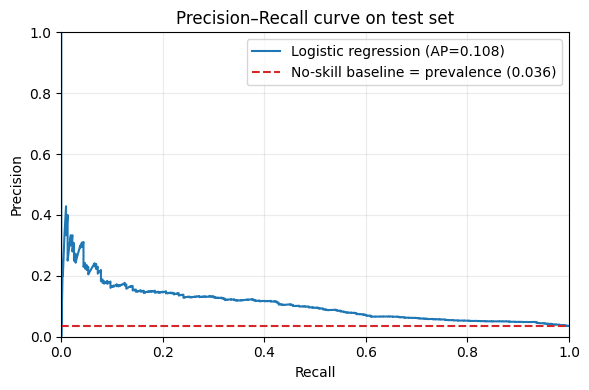

In [8]:
# TODO 2.2 — precision–recall curve พร้อมเส้น baseline = prevalence
# ======== Edit Code Here =============
prec, rec, thr = precision_recall_curve(y_test, proba_test)

fig, ax = plt.subplots(figsize=(6, 4))
# วาดเส้น PR curve, เส้นประแนวนอนที่ระดับ prevalence และใส่ label ให้ครบ
prevalence = y_test.mean()
ax.plot(rec, prec, label=f"Logistic regression (AP={average_precision_score(y_test, proba_test):.3f})")
ax.axhline(prevalence, color="tab:red", linestyle="--",
           label=f"No-skill baseline = prevalence ({prevalence:.3f})")
ax.set(xlabel="Recall", ylabel="Precision", title="Precision–Recall curve on test set")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(alpha=0.25); ax.legend()
# =====================================
plt.tight_layout(); plt.show()

**ข้อสังเกตงานที่ 2 (2 บรรทัด: เมทริกไหนแยกโมเดลกับ dummy ได้ และเมทริกไหนแยกไม่ได้):**

PR-AUC (0.1078 เทียบกับ 0.0356) และ ROC-AUC (0.7267 เทียบกับ 0.5000) แยก logistic regression จาก dummy ได้ เพราะวัดความสามารถในการจัดอันดับจาก score หลาย threshold  
Accuracy, balanced accuracy, MCC, precision, recall และ F1 แยกสองโมเดลไม่ได้ที่ threshold 0.5 เพราะทั้งคู่ทายคลาสบวก 0 เคส แม้ logistic regression จะจัดอันดับความเสี่ยงได้ดีกว่า

## งานที่ 3 — Threshold: แปลงข้อจำกัดของทีมงานเป็นตัวเลข (20 คะแนน)
ข้อจำกัดจากหัวข้อ "สถานการณ์" มีสองข้อ
- **กำลังคน:** ตรวจได้ไม่เกิน 8% ของใบสมัคร → `selection_rate ≤ 0.08`
- **ความน่าเชื่อถือ:** เปิดดู 10 เคสต้องเจอของจริงอย่างน้อย 1 เคส → `precision ≥ 0.10`

ให้เลือก threshold τ ที่ทำให้ **recall สูงที่สุด** ภายใต้ข้อจำกัดทั้งสอง โดยเลือกบน **validation set** เท่านั้น
แล้วจึงรายงานผลของ τ นั้นบน test set

In [9]:
# 3.0 — แยก validation ออกจาก train (ให้มาแล้ว ไม่ต้องแก้)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE)

model_v = Pipeline([("prep", make_prep()),
                    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
model_v.fit(X_tr2, y_tr2)
proba_val = model_v.predict_proba(X_val)[:, 1]
print("validation:", len(y_val), "แถว | คลาสบวก", int(y_val.sum()), "เคส")

validation: 5250 แถว | คลาสบวก 186 เคส


In [10]:
# TODO 3.1 — หา τ ที่ให้ recall สูงสุด ภายใต้ selection_rate <= 0.08 และ precision >= 0.10
# ======== Edit Code Here =============
candidates = []
for t in np.linspace(0.01, 0.9, 179):
    # คำนวณ pred, selection_rate, precision, recall บน validation
    # เก็บเฉพาะ threshold ที่ผ่านข้อจำกัดทั้งสองข้อ
    pred = (proba_val >= t).astype(int)
    selection_rate = pred.mean()
    precision = precision_score(y_val, pred, zero_division=0)
    recall = recall_score(y_val, pred, zero_division=0)
    if selection_rate <= 0.08 and precision >= 0.10:
        candidates.append({"threshold": t, "selection_rate": selection_rate,
                           "precision": precision, "recall": recall,
                           "n_review": int(pred.sum())})

cand = pd.DataFrame(candidates)
if cand.empty:
    raise ValueError("ไม่มี threshold ที่ผ่านข้อจำกัดทั้งสองข้อ")
# idxmax คืนค่าตัวแรกเมื่อ recall เท่ากัน; candidates เรียงจาก threshold ต่ำไปสูง
tau = cand.loc[cand["recall"].idxmax(), "threshold"]
# =====================================
print("τ ที่เลือก =", round(tau, 4))
cand.tail(10)

τ ที่เลือก = 0.08


,threshold,selection_rate,precision,recall,n_review
39,0.275,0.000571,0.666667,0.010753,3
40,0.280,0.000571,0.666667,0.010753,3
41,0.285,0.000571,0.666667,0.010753,3
42,0.290,0.000571,0.666667,0.010753,3
43,0.295,0.000381,1.000000,0.010753,2
44,0.300,0.000381,1.000000,0.010753,2
45,0.305,0.000381,1.000000,0.010753,2
46,0.310,0.000381,1.000000,0.010753,2
47,0.315,0.000190,1.000000,0.005376,1
48,0.320,0.000190,1.000000,0.005376,1


In [11]:
# TODO 3.2 — ใช้ τ กับ test set แล้วเทียบกับ threshold 0.5
# ======== Edit Code Here =============
proba_test_v = model_v.predict_proba(X_test)[:, 1]
pred_tau = (proba_test_v >= tau).astype(int)

# พิมพ์ตารางเปรียบเทียบ: threshold 0.5 vs τ (precision, recall, selection_rate, จำนวนเคสที่ต้องตรวจ)
threshold_rows = []
for label, pred in [("threshold 0.5", (proba_test_v >= 0.5).astype(int)),
                    (f"threshold τ={tau:.3f}", pred_tau)]:
    threshold_rows.append({
        "decision_rule": label,
        "prevalence": y_test.mean(),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "selection_rate": pred.mean(),
        "n_review": int(pred.sum()),
    })
pd.DataFrame(threshold_rows).set_index("decision_rule").round(4)
# =====================================


,prevalence,precision,recall,selection_rate,n_review
decision_rule,,,,,
threshold 0.5,0.0356,0.0000,0.0000,0.0000,0
threshold τ=0.080,0.0356,0.1228,0.2844,0.0823,741


**ข้อสังเกตงานที่ 3 (2 บรรทัด):** τ ที่เลือกคือเท่าไร ทีมงานต้องตรวจกี่เคส และได้ recall เท่าไร

เลือก $\tau=0.080$ จาก validation set เพราะให้ recall สูงที่สุดในบรรดาค่าที่มี selection rate ไม่เกิน 8% และ precision อย่างน้อย 10%  
เมื่อนำไปใช้กับ test set ทีมต้องตรวจ 741 จาก 9,000 เคส (8.23%) ได้ precision 12.28% และ recall 28.44%; ส่วน threshold 0.5 ไม่เลือกตรวจเลยและมี recall 0% (อัตรา 8.23% ที่เกินข้อจำกัดเล็กน้อยสะท้อนความคลาดเคลื่อนเมื่อใช้กับข้อมูลใหม่)

## งานที่ 4 — Resample ให้ถูกวิธี (30 คะแนน — งานหลักของแลปนี้)
เปรียบเทียบสามทางเลือกด้วย **PR-AUC จาก cross-validation บน training data** และ **PR-AUC บน test set**
1. `logreg` เปล่า ๆ
2. `logreg` + `class_weight="balanced"`
3. `logreg` + `SMOTE` ที่วางอยู่ **ภายใน** `imblearn.pipeline.Pipeline`

แล้วรันเซลล์ 4.3 ที่ **จงใจทำผิด** (SMOTE ก่อนแบ่งข้อมูล) เพื่อดูขนาดของภาพลวงตา

In [12]:
# TODO 4.1 — สร้างสามโมเดลให้ครบ
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# ======== Edit Code Here =============
models = {
    "logreg": Pipeline([("prep", make_prep()),
                        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
    "logreg + class_weight": Pipeline([
        ("prep", make_prep()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                   random_state=RANDOM_STATE))]),
    "logreg + SMOTE (ใน pipeline)": ImbPipeline([
        ("prep", make_prep()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
}
# =====================================
for k in models:
    print(k)

logreg
logreg + class_weight
logreg + SMOTE (ใน pipeline)


In [13]:
# TODO 4.2 — รายงาน CV PR-AUC (mean ± std) และ test PR-AUC ของทั้งสามโมเดล
# ======== Edit Code Here =============
results = []
dummy_cv = cross_val_score(DummyClassifier(strategy="most_frequent"), X_train, y_train,
                           cv=cv, scoring="average_precision")
results.append({"model": "dummy", "positive_rate": y_train.mean(),
                "CV PR-AUC mean": dummy_cv.mean(), "CV PR-AUC std": dummy_cv.std(),
                "test PR-AUC": average_precision_score(
                    y_test, dummy.predict_proba(X_test)[:, 1])})
for name, m in models.items():
    # cross_val_score ด้วย scoring="average_precision" บน X_train, y_train
    # แล้ว fit บน train ทั้งชุด และวัด average_precision_score บน test
    scores = cross_val_score(m, X_train, y_train, cv=cv, scoring="average_precision")
    m.fit(X_train, y_train)
    test_score = average_precision_score(y_test, m.predict_proba(X_test)[:, 1])
    results.append({"model": name, "positive_rate": y_train.mean(),
                    "CV PR-AUC mean": scores.mean(), "CV PR-AUC std": scores.std(),
                    "test PR-AUC": test_score})

pd.DataFrame(results).set_index("model").round(4)
# =====================================


,positive_rate,CV PR-AUC mean,CV PR-AUC std,test PR-AUC
model,,,,
dummy,0.0355,0.0355,0.0000,0.0356
logreg,0.0355,0.1125,0.0262,0.1078
logreg + class_weight,0.0355,0.1085,0.0214,0.1038
logreg + SMOTE (ใน pipeline),0.0355,0.1063,0.0232,0.1018


In [14]:
# 4.3 — จงใจทำผิด: SMOTE ก่อนแบ่งข้อมูล (รันแล้วสังเกต ไม่ต้องแก้)
if IMBLEARN:
    prep_all = make_prep()
    X_all_enc = prep_all.fit_transform(X_train)              # ยังอยู่ใน train เท่านั้น (ส่วนนี้ถูก)
    X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_all_enc, y_train)   # <-- ผิด: resample ก่อน CV

    wrong_cv = cross_val_score(LogisticRegression(max_iter=2000), X_res, y_res,
                               cv=cv, scoring="average_precision").mean()
    wrong_model = LogisticRegression(max_iter=2000).fit(X_res, y_res)
    wrong_test = average_precision_score(y_test, wrong_model.predict_proba(prep_all.transform(X_test))[:, 1])

    right_cv = cross_val_score(models["logreg + SMOTE (ใน pipeline)"], X_train, y_train,
                               cv=cv, scoring="average_precision").mean()
    right_test = average_precision_score(
        y_test, models["logreg + SMOTE (ใน pipeline)"].predict_proba(X_test)[:, 1])

    print(pd.DataFrame({
        "CV PR-AUC": [wrong_cv, right_cv],
        "test PR-AUC": [wrong_test, right_test],
    }, index=["SMOTE ก่อน CV (ผิด)", "SMOTE ใน pipeline (ถูก)"]).round(4))
    print("\nช่องว่างระหว่าง CV กับ test ของแถวแรก = ภาพลวงตาล้วน ๆ: %.3f PR-AUC"
          % (wrong_cv - wrong_test))

                         CV PR-AUC  test PR-AUC
SMOTE ก่อน CV (ผิด)         0.7111       0.1018
SMOTE ใน pipeline (ถูก)     0.1063       0.1018

ช่องว่างระหว่าง CV กับ test ของแถวแรก = ภาพลวงตาล้วน ๆ: 0.609 PR-AUC


**ข้อสังเกตงานที่ 4 (3 บรรทัด):**
- โมเดลไหนดีที่สุดเมื่อวัดด้วย PR-AUC บน test set
- ทางเลือกไหน "อธิบายง่ายที่สุด" เมื่อต้องเขียนลง Model Card และเพราะอะไร
- ช่องว่างในเซลล์ 4.3 เกิดจากอะไร (อธิบายเป็นกลไก ไม่ใช่แค่บอกว่า leakage)

- Logistic regression เปล่าดีที่สุดบน test set โดยมี PR-AUC 0.1078 เทียบกับ class weight 0.1038, SMOTE 0.1018 และ dummy/prevalence 0.0356
- Logistic regression เปล่าอธิบายลง Model Card ได้ง่ายที่สุด เพราะไม่มีการเปลี่ยนน้ำหนักคลาสหรือสร้างตัวอย่างสังเคราะห์ และ probability score ตีความ/ปรับ threshold ได้ตรงไปตรงมา
- การทำ SMOTE ก่อน CV ทำให้ตัวอย่างสังเคราะห์ที่สร้างจากเพื่อนบ้านของข้อมูลทั้งชุดกระจายข้าม training และ validation folds; validation จึงมีจุดที่สัมพันธ์ใกล้ชิดกับข้อมูลที่ใช้ฝึกอย่างผิดธรรมชาติ ทำให้ CV PR-AUC สูงเกินจริง

## งานที่ 5 — Audit: หา slice ที่โมเดลทำงานแย่ที่สุด (15 คะแนน)
ใช้โมเดลและ threshold τ จากงานที่ 3–4 แล้ว
1. เขียนฟังก์ชัน `slice_report` ที่คืน n, จำนวนเคสบวก, recall, precision และ selection_rate ของแต่ละกลุ่ม
2. รันกับ `age_band`, `region` และ `thin_file`
3. เปรียบเทียบสัดส่วน `region` ในข้อมูลกับสัดส่วนประชากรอ้างอิง (`POPULATION_SHARE`)
4. สรุปเป็น 5 ประโยค: slice ไหนแย่ที่สุด ขนาดเท่าไร เป็นอคติชนิดใด จะแก้อย่างไร และอะไรที่คำอธิบาย (SHAP/LIME) ทำให้ไม่ได้

In [15]:
# 5.0 — เตรียมตารางสำหรับตรวจสอบ (ให้มาแล้ว ไม่ต้องแก้)
# หมายเหตุ: τ ที่หาไว้ในงานที่ 3 เป็นของโมเดล logreg ตัวนั้นโดยเฉพาะ
# ถ้าเปลี่ยนโมเดล (เช่นไปใช้ class_weight) ต้องหา τ ใหม่เสมอ เพราะสเกลของความน่าจะเป็นเปลี่ยนไป
best = models["logreg"]
proba_audit = best.predict_proba(X_test)[:, 1]
pred_audit = (proba_audit >= tau).astype(int)

audit = X_test.copy()
audit["y_true"] = y_test.to_numpy()
audit["y_pred"] = pred_audit
audit["age_band"] = pd.cut(audit["age"], [19, 25, 40, 60, 120],
                           labels=["20–25", "26–40", "41–60", "60+"])
audit["thin_file"] = np.where(audit["credit_history_months"] < 12, "thin (<12 เดือน)", "thick")
audit.head(3)

,age,monthly_income,debt_to_income,credit_history_months,n_late_12m,loan_amount,employment_type,region,y_true,y_pred,age_band,thin_file
22571,45,35300.0,0.150,29,2,114800.0,self_employed,Central,0,0,41–60,thick
1346,46,26800.0,0.409,5,0,92900.0,salaried,Northeast,1,0,41–60,thin (<12 เดือน)
28693,20,6600.0,0.399,9,0,23200.0,salaried,Northeast,0,0,20–25,thin (<12 เดือน)


In [16]:
# TODO 5.1 — เขียน slice_report
def slice_report(frame, by, y_true="y_true", y_pred="y_pred"):
    """คืน DataFrame หนึ่งแถวต่อหนึ่งกลุ่ม เรียงจาก recall น้อยไปมาก"""
    out = []
    # ======== Edit Code Here =============
    # วนทีละกลุ่มด้วย frame.groupby(by, observed=True)
    # แต่ละแถวเก็บ: slice, n, positives, recall, precision, selection_rate
    for group, part in frame.groupby(by, observed=True):
        yt = part[y_true]
        yp = part[y_pred]
        out.append({
            "slice": group,
            "n": len(part),
            "positives": int(yt.sum()),
            "recall": recall_score(yt, yp, zero_division=0),
            "precision": precision_score(yt, yp, zero_division=0),
            "selection_rate": yp.mean(),
        })

    # =====================================
    return pd.DataFrame(out).sort_values("recall")

slice_report(audit, "age_band").round(3)

,slice,n,positives,recall,precision,selection_rate
3,60+,1026,22,0.136,0.041,0.071
2,41–60,3863,137,0.248,0.110,0.080
1,26–40,2946,111,0.360,0.157,0.087
0,20–25,1165,50,0.440,0.154,0.123


In [17]:
# TODO 5.2 — รันกับ region และ thin_file แล้วดูช่องว่างของ selection rate
# ======== Edit Code Here =============
overall = pd.DataFrame([{
    "slice": "overall", "n": len(audit), "positives": int(audit.y_true.sum()),
    "recall": recall_score(audit.y_true, audit.y_pred, zero_division=0),
    "precision": precision_score(audit.y_true, audit.y_pred, zero_division=0),
    "selection_rate": audit.y_pred.mean(),
}])
print("Overall")
print(overall.round(3).to_string(index=False))
for column in ["region", "thin_file"]:
    report = slice_report(audit, column)
    gap = report["selection_rate"].max() - report["selection_rate"].min()
    print(f"\nBy {column} (selection-rate gap = {gap:.3f})")
    print(report.round(3).to_string(index=False))

# =====================================


Overall
  slice    n  positives  recall  precision  selection_rate
overall 9000        320   0.309      0.127           0.087

By region (selection-rate gap = 0.162)
    slice    n  positives  recall  precision  selection_rate
    North 1033         40   0.200      0.182           0.043
  Central 2202         72   0.250      0.155           0.053
  Bangkok 3711        106   0.264      0.127           0.059
Northeast 1234         63   0.397      0.108           0.188
    South  820         39   0.513      0.119           0.205

By thin_file (selection-rate gap = 0.052)
           slice    n  positives  recall  precision  selection_rate
           thick 7229        231   0.303      0.127           0.076
thin (<12 เดือน) 1771         89   0.326      0.128           0.128


In [18]:
# 5.3 — representation check เทียบกับประชากรอ้างอิง (ให้มาแล้ว ไม่ต้องแก้)
share = df["region"].value_counts(normalize=True).rename("data_share")
ref = pd.Series(POPULATION_SHARE, name="population_share")
rep_tbl = pd.concat([share, ref], axis=1)
rep_tbl["ratio"] = (rep_tbl.data_share / rep_tbl.population_share).round(2)
print(rep_tbl.round(3))
print("\nratio > 1 = กลุ่มนั้นมีน้ำหนักเกินจริงในข้อมูล, ratio < 1 = ถูกเก็บมาน้อยกว่าที่ควร")

print("\nสัดส่วนค่าว่างของ monthly_income แยกตามความยาวประวัติเครดิต:")
print(df.assign(thin=np.where(df.credit_history_months < 12, "thin (<12 เดือน)", "thick"))
        .groupby("thin")["monthly_income"].apply(lambda s: s.isna().mean()).round(3))

           data_share  population_share  ratio
Bangkok         0.414              0.16   2.59
Central         0.242              0.22   1.10
Northeast       0.139              0.33   0.42
North           0.117              0.17   0.69
South           0.088              0.12   0.73

ratio > 1 = กลุ่มนั้นมีน้ำหนักเกินจริงในข้อมูล, ratio < 1 = ถูกเก็บมาน้อยกว่าที่ควร

สัดส่วนค่าว่างของ monthly_income แยกตามความยาวประวัติเครดิต:
thin
thick               0.051
thin (<12 เดือน)    0.281
Name: monthly_income, dtype: float64


**คำตอบงานที่ 5 (5 ประโยค):**

1. slice ที่แย่ที่สุดคือกลุ่มอายุ `60+` (n = 1,026, เคสบวก = 22)
2. ตัวเลขที่ใช้ตัดสินคือ recall 0.136 เทียบกับ recall รวม 0.309 โดยกลุ่มนี้มี precision 0.041 และ selection rate 0.071
3. อคตินี้น่าจะมาจาก **aggregation bias** เพราะความสัมพันธ์ระหว่าง feature กับการผิดนัดของผู้สูงอายุแตกต่างจากกลุ่มทั่วไป ขณะที่ข้อมูลยังมี representation bias ตามภูมิภาคและ measurement bias ในกลุ่ม thin file ประกอบด้วย
4. แนวทางแก้แรกคือเก็บข้อมูลเคสบวกของผู้สูงอายุเพิ่ม แล้วฝึก/ตรวจสอบโมเดลที่รองรับความสัมพันธ์เฉพาะกลุ่มบน validation เพราะกลุ่มนี้มีเคสบวกเพียง 22 เคสใน test และกฎรวมแบบเดียวจับรูปแบบได้ไม่ดี
5. SHAP/LIME บอกได้ว่าโมเดลใช้ feature ใดในการทำนายแต่ละเคส แต่ยืนยันไม่ได้ว่าข้อมูลเป็นตัวแทนประชากร ค่าวัดถูกต้อง เหตุใดข้อมูลจึงหาย หรือการตัดสินนั้นยุติธรรมเชิงสาเหตุ

---
## เกณฑ์การให้คะแนน (Rubric — รวม 100)

| งาน | คะแนน | ดีมาก (เต็ม) | พอใช้ (ครึ่ง) | ต้องปรับปรุง (0–20%) |
|---|---|---|---|---|
| 1 Diagnose | 15 | แบ่งข้อมูลด้วย `stratify` ก่อนทำอะไรทั้งสิ้น · รายงานสัดส่วนคลาสครบสามชุด · แสดง accuracy, recall, balanced accuracy และ confusion matrix ของ dummy พร้อมข้อสังเกตที่ชี้ว่า accuracy = 1 − prevalence | แสดงตัวเลขครบแต่ข้อสังเกตตื้น หรือไม่ได้เชื่อมโยง accuracy กับสัดส่วนคลาส | ไม่ได้แบ่งข้อมูลก่อน หรือรันไม่ผ่าน |
| 2 Metrics | 20 | ตารางมี dummy และ baseline อยู่ด้วยกัน ครบทุกเมทริก · PR curve มีเส้น baseline ที่ระดับ prevalence · ระบุได้ว่าเมทริกใดแยกสองโมเดลได้และเมทริกใดแยกไม่ได้ | ตารางหรือกราฟครบแต่ขาดการอ่านผล หรือลืมเส้น baseline | รายงานเฉพาะ accuracy หรือไม่มีค่าของ dummy ให้เทียบ |
| 3 Threshold | 20 | เลือก τ บน validation เท่านั้น · ระบุข้อจำกัดทั้งสองข้อที่ τ ต้องผ่าน · เทียบกับ threshold 0.5 พร้อมจำนวนเคสที่ทีมต้องตรวจ | ได้ τ ที่สมเหตุสมผลแต่เลือกจาก F1 ล้วน ๆ โดยไม่อ้างข้อจำกัด | เลือก τ บน test set หรือใช้ 0.5 โดยไม่ตรวจสอบ |
| 4 Resample | 30 | SMOTE อยู่ใน `ImbPipeline` เท่านั้น · รายงานทั้ง CV และ test ของทั้งสามโมเดลพร้อม dummy · อธิบายกลไกของช่องว่างในเซลล์ 4.3 ได้ว่าจุดสังเคราะห์รั่วข้าม fold อย่างไร · สรุปได้ว่าทางเลือกใดอธิบายง่ายที่สุดใน Model Card | ตารางครบแต่คำอธิบายกลไกไม่ถูกต้อง หรือบอกแค่ว่า "เกิด leakage" | วาง SMOTE นอก pipeline, resample ชุด test หรือรายงานเฉพาะ CV |
| 5 Audit | 15 | `slice_report` คืน `n` และ `positives` ครบ เรียงตาม recall · ระบุ slice ที่แย่ที่สุดพร้อมขนาด · เรียกชื่อแหล่งของอคติได้ถูกต้อง และบอกได้ว่าคำอธิบายทำอะไรไม่ได้ | หา slice ที่แย่ที่สุดเจอ แต่ระบุแหล่งของอคติผิด หรือไม่รายงานขนาดของกลุ่ม | ดูเฉพาะตัวเลขรวม ไม่มีการหั่น slice |

**การหักคะแนน:** ส่งช้าหัก 10% ต่อวัน และไม่รับงานที่ส่งช้าเกิน 7 วัน (ตามข้อกำหนดรายวิชา) · ไฟล์ที่ไม่มีผลลัพธ์ของการรันจะไม่ได้รับการตรวจ